<center><u><H1>Seaborn-Categorical Data</H1></u></center>

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

In [6]:
tips = sns.load_dataset("tips")
iris = sns.load_dataset("iris")

In [3]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [7]:
iris.species.unique()

<StringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str

## <u>Categorical Plots:</u>

### Basic Scatter Plot:

<Axes: xlabel='sepal_length', ylabel='sepal_width'>

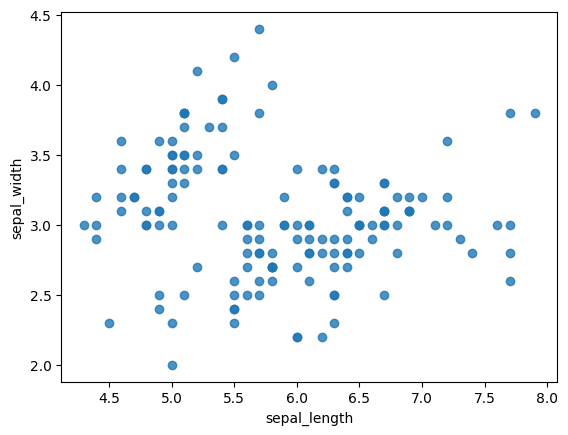

In [8]:
sns.regplot(x=iris["sepal_length"], y=iris["sepal_width"],fit_reg=False)

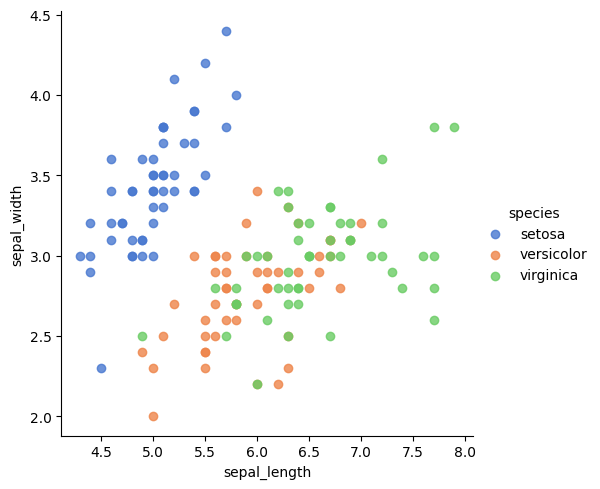

In [9]:
sns.lmplot(x="sepal_length", y="sepal_width", data=iris, hue="species", fit_reg=False, palette="muted",legend=True)

### Stripplot:

<Axes: xlabel='day', ylabel='total_bill'>

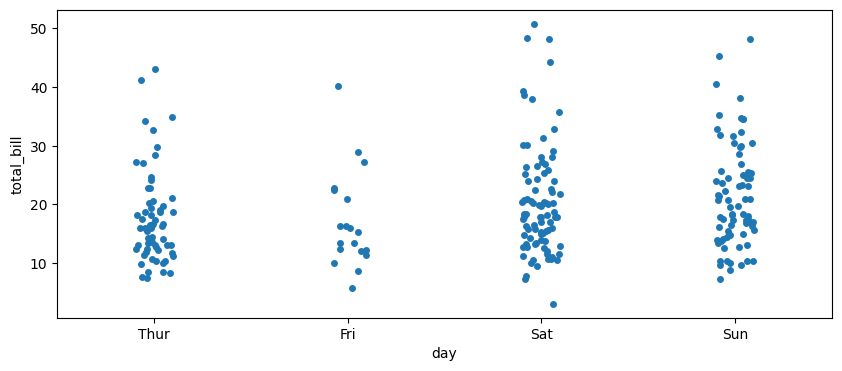

In [10]:
#axes level function:
fig, ax = plt.subplots(figsize=(10,4))
sns.stripplot(x="day", y="total_bill", data=tips)

<Axes: xlabel='day', ylabel='total_bill'>

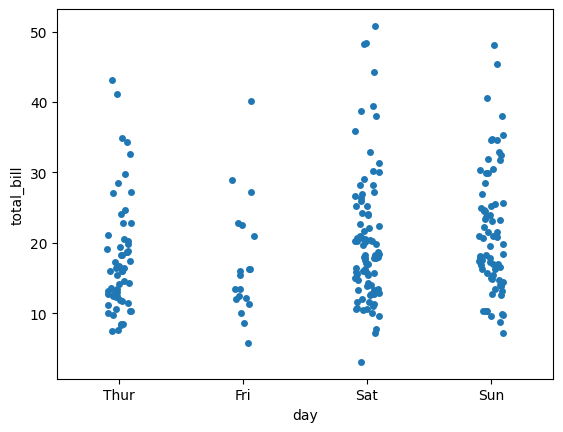

In [11]:
sns.stripplot(x="day", y="total_bill", data=tips, jitter=True) # jitter to avoid overlapping in the scatterplot points

### Boxplot:

<Axes: xlabel='day', ylabel='total_bill'>

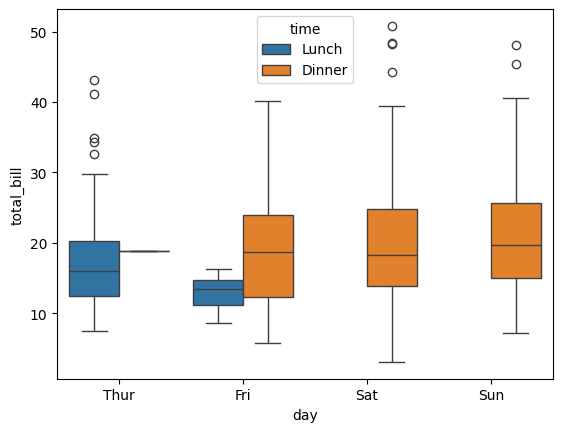

In [12]:
sns.boxplot(x="day", y="total_bill", hue="time", data=tips)

### Violin Plot:

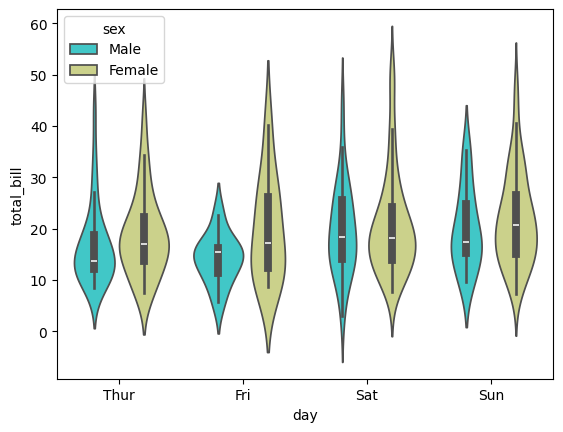

In [13]:
ax=sns.violinplot(x="day",y="total_bill", data=tips, palette="rainbow", hue='sex')

### Bar Plot:

<Axes: xlabel='species', ylabel='sepal_length'>

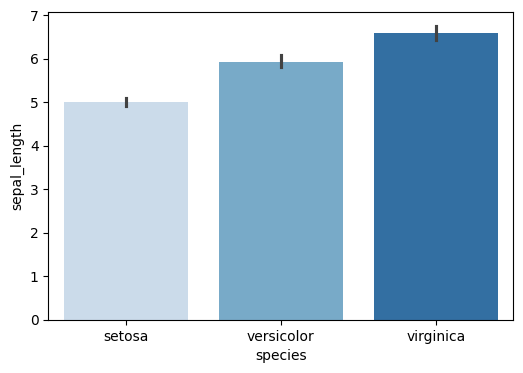

In [15]:
fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(x=iris.species, y=iris.sepal_length, hue=iris.species, palette="Blues", data=iris, ax=ax, estimator=lambda x: sum(x)/len(x))

### Count Plot:

<Axes: xlabel='species', ylabel='count'>

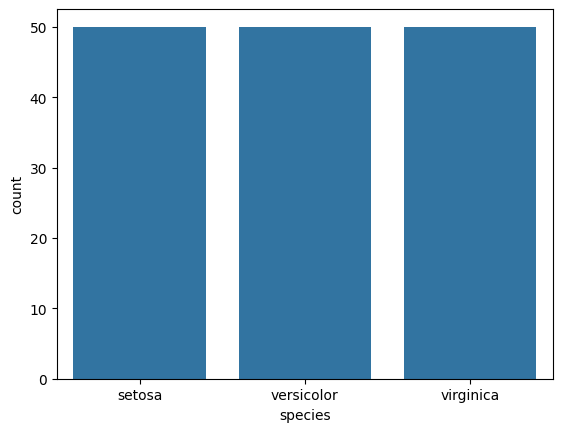

In [16]:
sns.countplot(x='species',data=iris)

### Scatter Plot Matrix: Pairplot () function

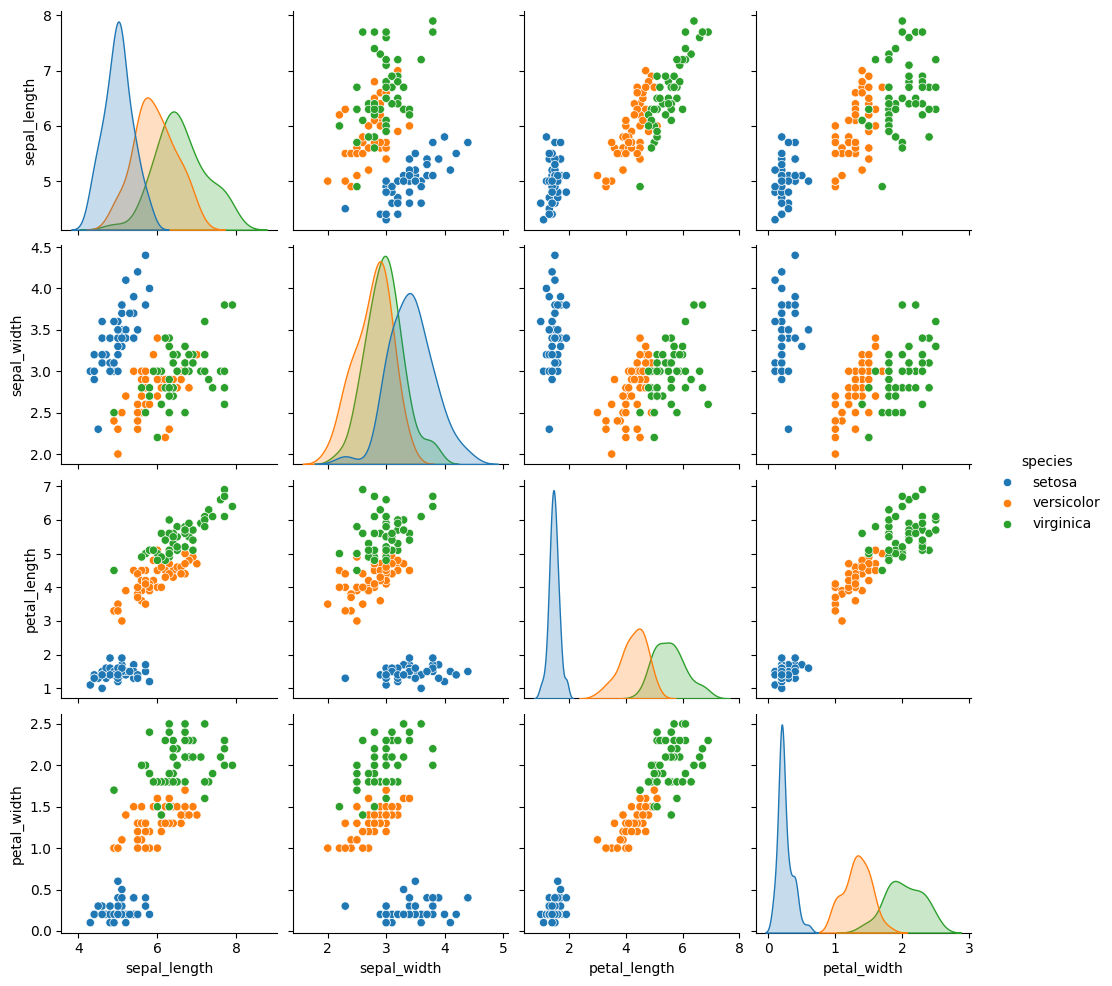

In [17]:
sns.pairplot(iris, hue="species")

## Facet Grid:
Is used to draw plots with multiple Axes where each Axes shows the same relationship conditioned on different levels of some variable. It’s possible to condition on up to three variables by assigning variables to the rows and columns of the grid and using different colors for the plot elements.
The basic workflow is to initialize the FacetGrid object with the dataset and the variables that are used to structure the grid. Then one or more plotting functions can be applied to each subset by calling FacetGrid.map() or FacetGrid.map_dataframe(). Finally, the plot can be tweaked with other methods to do things like change the axis labels, use different ticks, or add a legend. 

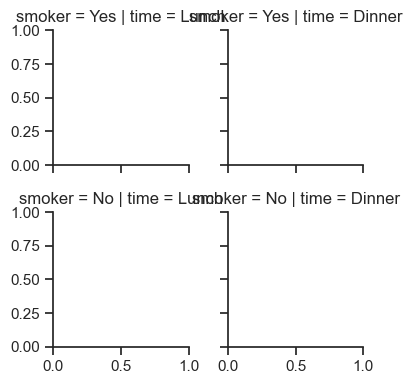

In [19]:
sns.set(style="ticks")
plot = sns.FacetGrid(tips, col="time", row="smoker", height=2)

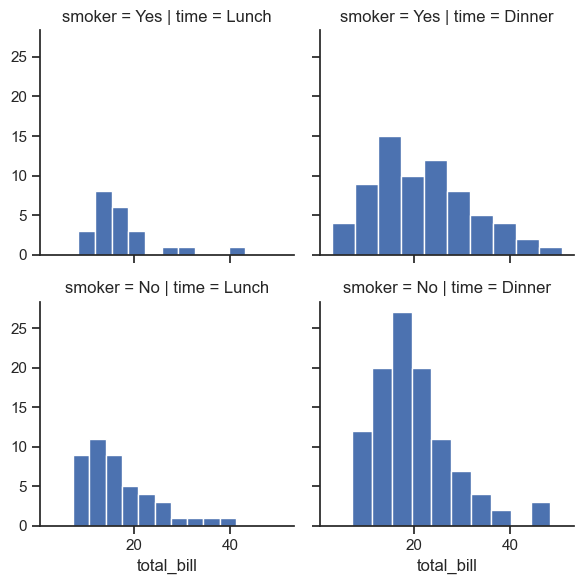

In [20]:
plot = sns.FacetGrid(tips, col="time",  row="smoker")
plot = plot.map(plt.hist, "total_bill")

### Change the size and aspect ratio of each facet:

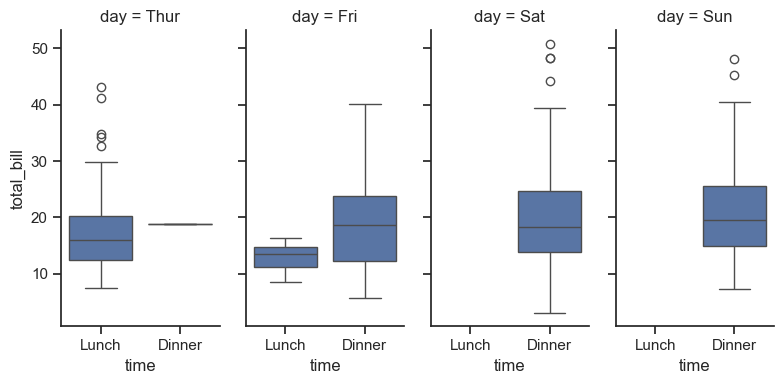

In [23]:
plot = sns.FacetGrid(tips, col="day", height=4, aspect=.5)
plot = plot.map(sns.boxplot, "time", "total_bill", order=["Lunch", "Dinner"])

### Setting the color palette:

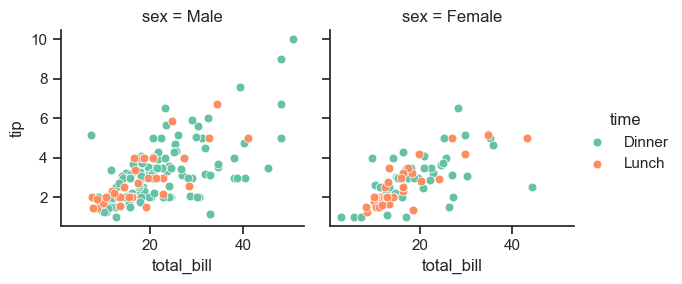

In [24]:
kws = dict(s=40, linewidth=.5, edgecolor="w")
plot = sns.FacetGrid(tips, col="sex", hue="time", palette="Set2",
                  hue_order=["Dinner", "Lunch"])
plot = (plot.map(plt.scatter, "total_bill", "tip", **kws)
     .add_legend())

### Use a different marker for the hue levels:

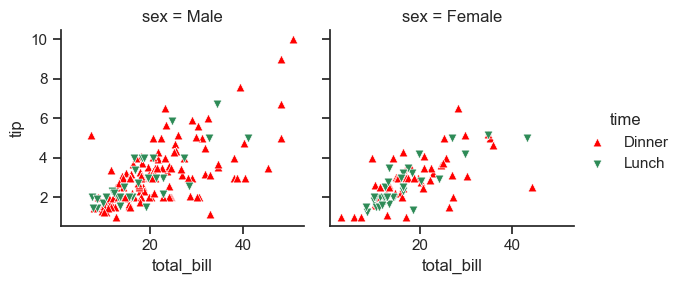

In [25]:
pal = dict(Lunch="seagreen", Dinner="red")
plot = sns.FacetGrid(tips, col="sex", hue="time", palette=pal,
                  hue_order=["Dinner", "Lunch"],
                  hue_kws=dict(marker=["^", "v"]))
plot = (plot.map(plt.scatter, "total_bill", "tip", **kws)
     .add_legend())

## Reference:

http://seaborn.pydata.org/tutorial/categorical.html